# Premier League Match Outcome Prediction
This notebook trains a machine learning model to predict the outcome of Premier League matches based on historical data.



# 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, brier_score_loss
from sklearn.preprocessing import LabelEncoder
import joblib
# import xgboost as xgb

sns.set_style('whitegrid')

# 2. Load the Dataset


In [13]:

matches = pd.read_csv("matches_all.csv")
matches["Date"] = pd.to_datetime(matches["Date"])
matches.head()


,Date,Season,Home,Away,HomeGoals,AwayGoals,Result,OddsH,OddsD,OddsA,Venue,Referee,Status
0,2021-08-13,2021/2022,Brentford,Arsenal,2,0,H,4.00,3.40,1.95,NaN,NaN,FT
1,2021-08-14,2021/2022,Manchester United,Leeds United,5,1,H,1.53,4.50,5.75,NaN,NaN,FT
2,2021-08-14,2021/2022,Burnley,Brighton,1,2,A,3.10,3.10,2.45,NaN,NaN,FT
3,2021-08-14,2021/2022,Chelsea,Crystal Palace,3,0,H,1.25,5.75,13.00,NaN,NaN,FT
4,2021-08-14,2021/2022,Everton,Southampton,3,1,H,1.90,3.50,4.00,NaN,NaN,FT



# 3. Exploratory Data Analysis (EDA)


Dataset shape: (1520, 13)
Missing values:
 Date            0
Season          0
Home            0
Away            0
HomeGoals       0
AwayGoals       0
Result          0
OddsH           0
OddsD           0
OddsA           0
Venue        1520
Referee      1520
Status          0
dtype: int64


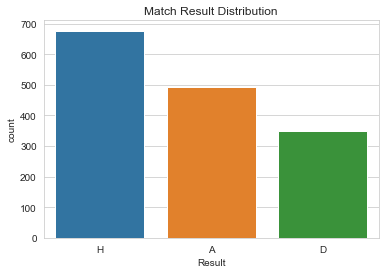

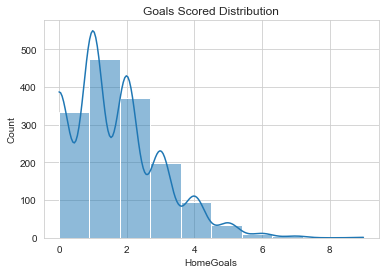

In [14]:
# 3. Exploratory Data Analysis (EDA)
print("Dataset shape:", matches.shape)
print("Missing values:\n", matches.isna().sum())

# Result distribution
sns.countplot(x="Result", data=matches)
plt.title("Match Result Distribution")
plt.show()

# Goals scored distribution
sns.histplot(matches["HomeGoals"], bins=10, kde=True)
plt.title("Goals Scored Distribution")
plt.show()

# 4. Data Visualisation

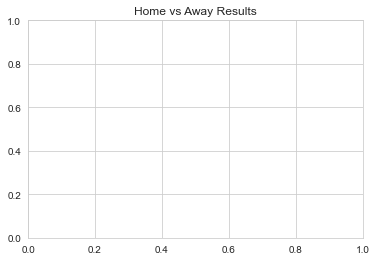

In [15]:
# Example: Home vs Away wins
#sns.countplot(x="Result", hue="Venue", data=matches)
plt.title("Home vs Away Results")
plt.show()

# 5. Data Preprocessing


In [16]:
# 5. Data Preprocessing

# Encode categorical features
matches["Team_Code"]     = matches["Home"].astype("category").cat.codes
matches["Opponent_Code"] = matches["Away"].astype("category").cat.codes
matches["Venue_Code"]    = matches["Venue"].fillna("Unknown").astype("category").cat.codes
matches["Day_Code"]      = matches["Date"].dt.dayofweek
matches["Hour"]          = 15  # default, API data doesn't include kick-off time on free plan

# Target variable (1 = home win)
matches["Target"] = (matches["Result"] == "H").astype(int)

# Points for rolling form (from home team perspective)
matches["Points"] = matches["Result"].map({"H": 3, "D": 1, "A": 0})
matches["GF"]     = matches["HomeGoals"]
matches["GA"]     = matches["AwayGoals"]


matches["OddsH"] = matches["OddsH"].fillna(matches["OddsH"].mean())
matches["OddsD"] = matches["OddsD"].fillna(matches["OddsD"].mean())
matches["OddsA"] = matches["OddsA"].fillna(matches["OddsA"].mean())

# Convert odds to implied probabilities (removes bookmaker vig)
raw_sum = 1/matches["OddsH"] + 1/matches["OddsD"] + 1/matches["OddsA"]
matches["ProbH"] = (1/matches["OddsH"]) / raw_sum
matches["ProbD"] = (1/matches["OddsD"]) / raw_sum
matches["ProbA"] = (1/matches["OddsA"]) / raw_sum

# Sort by date
matches = matches.sort_values(["Home", "Date"])

# Rolling features
def add_rolling_features(df, team_col="Home", cols=["Points","GF","GA"], window=5):
    result = df.copy()
    for c in cols:
        result[f"{c}_form{window}"] = df.groupby(team_col)[c].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
    return result

matches = add_rolling_features(matches, cols=["Points","GF","GA"], window=5)
matches = matches.dropna(subset=["Points_form5","GF_form5","GA_form5"])
matches.head()

,Date,Season,Home,Away,HomeGoals,AwayGoals,Result,OddsH,OddsD,OddsA,...,Target,Points,GF,GA,ProbH,ProbD,ProbA,Points_form5,GF_form5,GA_form5
35,2021-09-11,2021/2022,Arsenal,Norwich,1,0,H,1.50,4.60,6.0,...,1,3,1,0,0.634483,0.206897,0.158621,0.00,0.000000,2.00
58,2021-09-26,2021/2022,Arsenal,Tottenham,3,1,H,2.15,3.30,3.5,...,1,3,3,1,0.441345,0.287543,0.271112,1.50,0.500000,1.00
79,2021-10-18,2021/2022,Arsenal,Crystal Palace,2,2,D,1.60,3.80,6.0,...,0,1,2,2,0.592516,0.249480,0.158004,2.00,1.333333,1.00
80,2021-10-22,2021/2022,Arsenal,Aston Villa,3,1,H,1.83,3.75,4.2,...,1,3,3,1,0.519828,0.253676,0.226496,1.75,1.500000,1.25
106,2021-11-07,2021/2022,Arsenal,Watford,1,0,H,1.36,4.75,8.5,...,1,3,1,0,0.691412,0.197962,0.110626,2.00,1.800000,1.20


In [17]:
# Streak features
def add_streaks(df):
    df = df.copy()
    
    win_streak      = []
    loss_streak     = []
    unbeaten_streak = []
    
    for team, group in df.groupby("Home"):
        w, l, u = 0, 0, 0
        streaks_w, streaks_l, streaks_u = [], [], []
        
        for result in group["Result"]:
            streaks_w.append(w)
            streaks_l.append(l)
            streaks_u.append(u)
            if result == "H":
                w += 1; l = 0; u += 1
            elif result == "D":
                w = 0; l = 0; u += 1
            else:
                w = 0; l += 1; u = 0
        
        win_streak.extend(streaks_w)
        loss_streak.extend(streaks_l)
        unbeaten_streak.extend(streaks_u)
    
    df["WinStreak"]      = win_streak
    df["LossStreak"]     = loss_streak
    df["UnbeatenStreak"] = unbeaten_streak
    return df

matches = add_streaks(matches)

# 6. Model Training

In [18]:
# Train/test split based on date
train = matches[matches["Date"] <= "2022-01-01"]
test = matches[matches["Date"] > "2022-01-01"]

predictors = ["Team_Code", "Opponent_Code", "Venue_Code", "Hour", "Day_Code",
              "Points_form5", "GF_form5", "GA_form5",
              "ProbH", "ProbD", "ProbA",
              "WinStreak", "LossStreak", "UnbeatenStreak"]

rf = RandomForestClassifier(n_estimators=200, min_samples_split=10, random_state=42)
rf.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 7. Model Evaluation

Accuracy: 0.6618975903614458
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       730
           1       0.65      0.55      0.60       598

    accuracy                           0.66      1328
   macro avg       0.66      0.65      0.65      1328
weighted avg       0.66      0.66      0.66      1328



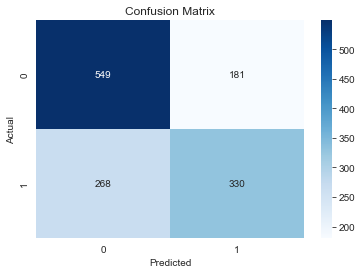

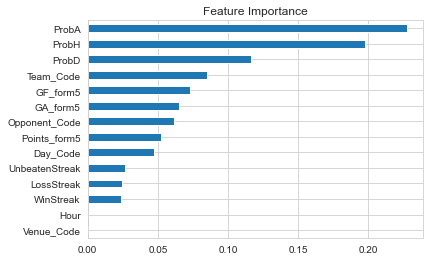

In [19]:
preds = rf.predict(test[predictors])

# Accuracy
print("Accuracy:", accuracy_score(test["Target"], preds))

# Classification report
print(classification_report(test["Target"], preds))

# Confusion matrix
cm = confusion_matrix(test["Target"], preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature importance
importances = rf.feature_importances_
pd.Series(importances, index=predictors).sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

# 8. Hyperparameter Tuning

In [20]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [5, 10, 15],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(train[predictors], train["Target"])

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Train best model
best_rf = grid.best_estimator_

Best params: {'max_depth': 5, 'min_samples_split': 15, 'n_estimators': 200}
Best CV score: 0.6871212121212121


# 9. Save the model 
for future use

In [24]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(best_rf, "models/premier_league_model.pkl")
joblib.dump(predictors, "models/predictors.pkl")  # ← add this
print("Model saved!")

Model saved!


# 10. Conclusion and Next Steps

In [ ]:
"""
- Model trained using historical Premier League data.
- Rolling form and goals features improve predictions.
- Random Forest is baseline; can try Gradient Boosting next (XGBoost/LightGBM).
- Next steps:
    1. Add betting odds and streak features.
    2. Add player-level stats for top scorers.
    3. Use this trained model in Streamlit or FastAPI app.
"""

'\n- Model trained using historical Premier League data.\n- Rolling form and goals features improve predictions.\n- Random Forest is baseline; can try Gradient Boosting next (XGBoost/LightGBM).\n- Next steps:\n    1. Add betting odds and streak features.\n    2. Add player-level stats for top scorers.\n    3. Use this trained model in Streamlit or FastAPI app.\n'